# Download counts for nteract desktop releases

This notebook fetches GitHub release assets from `nteract/desktop` and focuses on the published desktop installers for the stable and nightly release streams.

In [1]:
import IPython.display
import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

In [2]:
response = requests.get(
    "https://api.github.com/repos/nteract/desktop/releases",
    headers={"Accept": "application/vnd.github+json"},
    timeout=30,
)
response.raise_for_status()
data = response.json()

In [3]:
[
    {
        "tag_name": release["tag_name"],
        "prerelease": release["prerelease"],
        "published_at": release["published_at"],
    }
    for release in data[:5]
]

[{'tag_name': 'v2.0.0-nightly.202603131713',
  'prerelease': True,
  'published_at': '2026-03-13T17:26:54Z'},
 {'tag_name': 'v2.0.0-nightly.202603131605',
  'prerelease': True,
  'published_at': '2026-03-13T16:37:47Z'},
 {'tag_name': 'v2.0.0-nightly.202603131409',
  'prerelease': True,
  'published_at': '2026-03-13T14:43:07Z'},
 {'tag_name': 'v2.0.0-nightly.202603121904',
  'prerelease': True,
  'published_at': '2026-03-12T19:39:13Z'},
 {'tag_name': 'v2.0.0-nightly.202603120914',
  'prerelease': True,
  'published_at': '2026-03-12T09:37:19Z'}]

`nteract/desktop` releases publish more than just end-user installers: updater manifests, updater bundles, signatures, CLI binaries, and Python wheels also show up as assets. We filter the results down to desktop installers and derive both the release stream (`stable` vs `nightly`) and the platform from the asset filename.

In [4]:
import re

STREAM_PATTERN = re.compile(r"-(stable|nightly)\.")
INSTALLER_PATTERN = re.compile(
    r"^nteract-(stable|nightly)-(?P<platform>darwin-arm64|windows-x64|linux-x64)\.(?P<ext>dmg|exe|AppImage|deb)$"
)

PLATFORM_LABELS = {
    ("darwin-arm64", "dmg"): "macOS arm64 (.dmg)",
    ("windows-x64", "exe"): "Windows x64 (.exe)",
    ("linux-x64", "AppImage"): "Linux x64 (.AppImage)",
    ("linux-x64", "deb"): "Linux x64 (.deb)",
}


def release_stream(tag_name):
    match = STREAM_PATTERN.search(tag_name)
    return match.group(1) if match else None


def parse_installer_asset(asset_name):
    match = INSTALLER_PATTERN.match(asset_name)
    if not match:
        return None

    platform = match.group("platform")
    extension = match.group("ext")

    return {
        "platform_key": platform,
        "platform": PLATFORM_LABELS[(platform, extension)],
        "extension": extension,
    }

In [5]:
rows = []

for release in data:
    stream = release_stream(release["tag_name"])
    if stream is None:
        continue

    for asset in release["assets"]:
        installer = parse_installer_asset(asset["name"])
        if not installer:
            continue

        rows.append(
            {
                "release": release["tag_name"],
                "stream": stream,
                "published_at": release["published_at"],
                "platform": installer["platform"],
                "platform_key": installer["platform_key"],
                "asset": asset["name"],
                "count": asset["download_count"],
            }
        )

releases = pd.DataFrame(rows)
releases["published_at"] = pd.to_datetime(releases["published_at"])
releases.sort_values(["published_at", "stream", "platform"], inplace=True)
releases.tail(8)

,release,stream,published_at,platform,platform_key,asset,count
5,v2.0.0-nightly.202603131605,nightly,2026-03-13 16:37:47+00:00,Linux x64 (.AppImage),linux-x64,nteract-nightly-linux-x64.AppImage,0
6,v2.0.0-nightly.202603131605,nightly,2026-03-13 16:37:47+00:00,Linux x64 (.deb),linux-x64,nteract-nightly-linux-x64.deb,0
7,v2.0.0-nightly.202603131605,nightly,2026-03-13 16:37:47+00:00,Windows x64 (.exe),windows-x64,nteract-nightly-windows-x64.exe,0
4,v2.0.0-nightly.202603131605,nightly,2026-03-13 16:37:47+00:00,macOS arm64 (.dmg),darwin-arm64,nteract-nightly-darwin-arm64.dmg,0
1,v2.0.0-nightly.202603131713,nightly,2026-03-13 17:26:54+00:00,Linux x64 (.AppImage),linux-x64,nteract-nightly-linux-x64.AppImage,0
2,v2.0.0-nightly.202603131713,nightly,2026-03-13 17:26:54+00:00,Linux x64 (.deb),linux-x64,nteract-nightly-linux-x64.deb,0
3,v2.0.0-nightly.202603131713,nightly,2026-03-13 17:26:54+00:00,Windows x64 (.exe),windows-x64,nteract-nightly-windows-x64.exe,0
0,v2.0.0-nightly.202603131713,nightly,2026-03-13 17:26:54+00:00,macOS arm64 (.dmg),darwin-arm64,nteract-nightly-darwin-arm64.dmg,0


In [6]:
summary = releases.pivot_table(
    index=["stream", "release"],
    columns="platform",
    values="count",
    aggfunc="sum",
    fill_value=0,
).reset_index()
summary.tail(10)

platform,stream,release,Linux x64 (.AppImage),Linux x64 (.deb),Windows x64 (.exe),macOS arm64 (.dmg)
19,nightly,v2.0.0-nightly.202603120129,1,1,0,1
20,nightly,v2.0.0-nightly.202603120914,0,0,1,0
21,nightly,v2.0.0-nightly.202603121904,0,0,0,0
22,nightly,v2.0.0-nightly.202603131409,0,0,0,0
23,nightly,v2.0.0-nightly.202603131605,0,0,0,0
24,nightly,v2.0.0-nightly.202603131713,0,0,0,0
25,stable,v1.4.1-stable.202603090259,1,1,4,1
26,stable,v1.4.1-stable.202603091428,1,1,1,3
27,stable,v1.4.1-stable.202603091829,8,1,5,10
28,stable,v1.4.1-stable.202603102148,5,0,3,5


In [9]:
recent_release_order = (
    releases[["stream", "release", "published_at"]]
    .drop_duplicates()
    .sort_values(["stream", "published_at"])
    .groupby("stream")
    .tail(6)
)

plot_df = releases.merge(
    recent_release_order[["stream", "release"]],
    on=["stream", "release"],
    how="inner",
).copy()

release_order_by_stream = (
    recent_release_order.groupby("stream")["release"].agg(list).to_dict()
)

recent_release_order

,stream,release,published_at
21,nightly,v2.0.0-nightly.202603120129,2026-03-12 02:02:42+00:00
17,nightly,v2.0.0-nightly.202603120914,2026-03-12 09:37:19+00:00
13,nightly,v2.0.0-nightly.202603121904,2026-03-12 19:39:13+00:00
9,nightly,v2.0.0-nightly.202603131409,2026-03-13 14:43:07+00:00
5,nightly,v2.0.0-nightly.202603131605,2026-03-13 16:37:47+00:00
1,nightly,v2.0.0-nightly.202603131713,2026-03-13 17:26:54+00:00
69,stable,v1.4.1-stable.202603090259,2026-03-09 03:11:28+00:00
65,stable,v1.4.1-stable.202603091428,2026-03-09 14:41:21+00:00
61,stable,v1.4.1-stable.202603091829,2026-03-09 18:43:13+00:00
41,stable,v1.4.1-stable.202603102148,2026-03-10 22:02:17+00:00


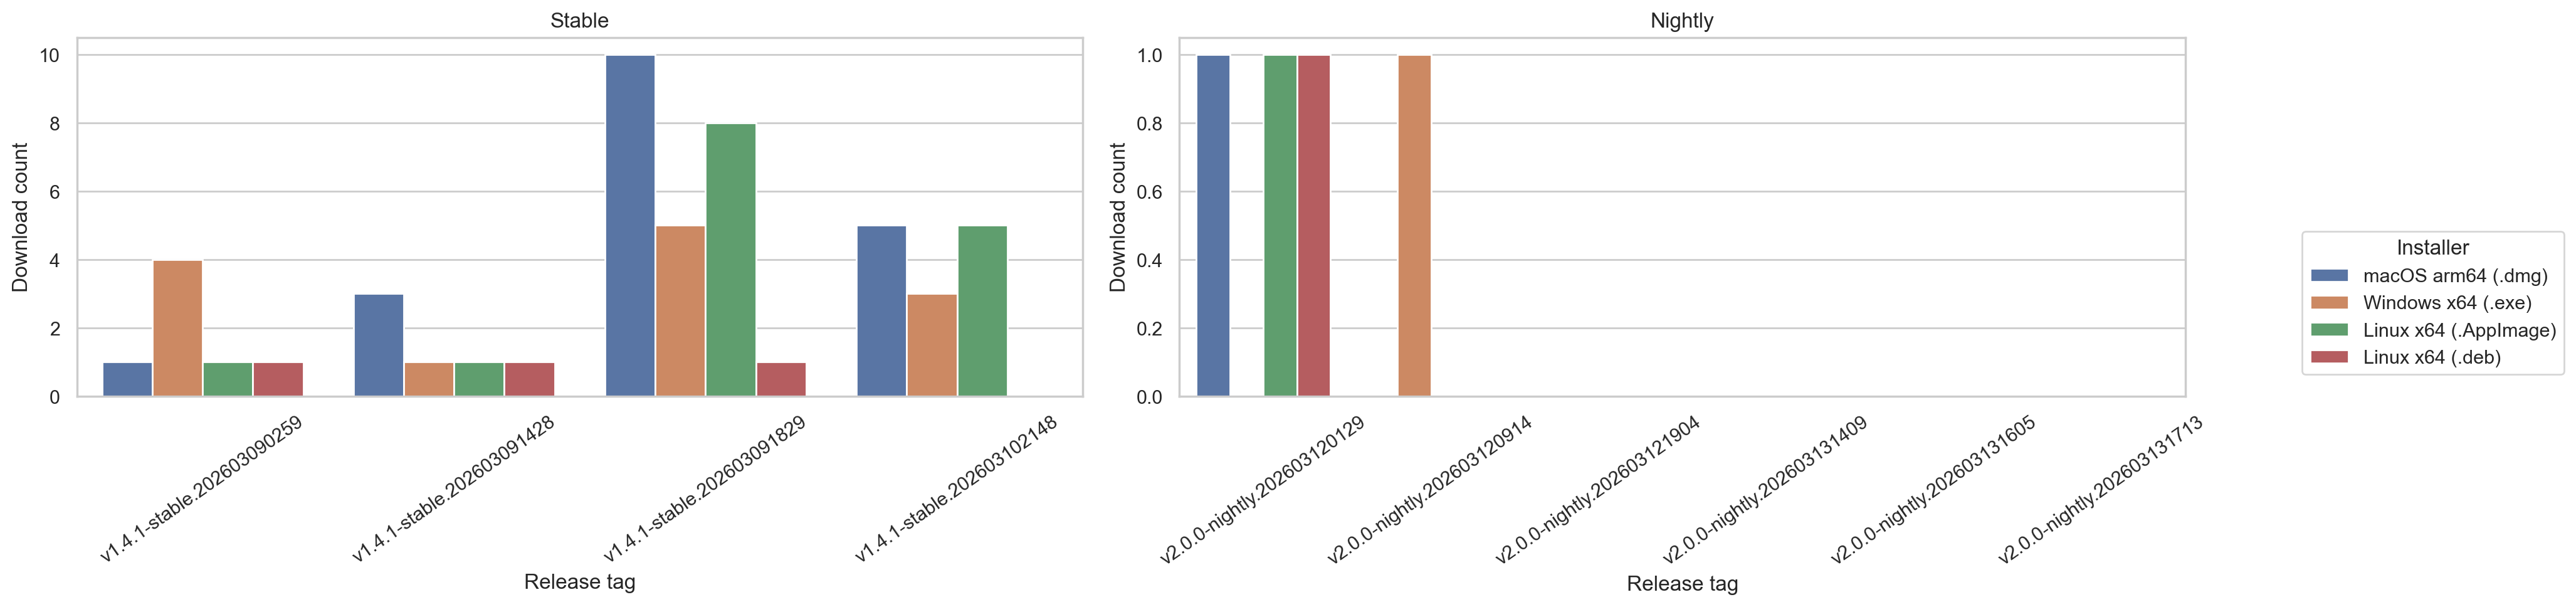

In [10]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

sns.set_theme(style="whitegrid")

stream_order = [stream for stream in ["stable", "nightly"] if stream in release_order_by_stream]
hue_order = [
    label
    for label in [
        "macOS arm64 (.dmg)",
        "Windows x64 (.exe)",
        "Linux x64 (.AppImage)",
        "Linux x64 (.deb)",
    ]
    if label in plot_df["platform"].unique()
]

fig, axes = plt.subplots(1, len(stream_order), figsize=(9 * len(stream_order), 5), squeeze=False)
legend_handles = None
legend_labels = None

for ax, stream in zip(axes[0], stream_order):
    stream_df = plot_df[plot_df["stream"] == stream]
    sns.barplot(
        data=stream_df,
        x="release",
        y="count",
        hue="platform",
        order=release_order_by_stream[stream],
        hue_order=hue_order,
        ax=ax,
    )
    ax.set_title(stream.title())
    ax.set_xlabel("Release tag")
    ax.set_ylabel("Download count")
    ax.tick_params(axis="x", rotation=35)

    handles, labels = ax.get_legend_handles_labels()
    if legend_handles is None:
        legend_handles, legend_labels = handles, labels
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.legend(legend_handles, legend_labels, title="Installer", loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
plt.show()